# MINI PROYECTO INTEGRADOR

Objetivo:
Desarrollar un pequeño proyecto aplicando regresión lineal para predecir precios o rendimientos de un activo financiero elegido por el alumno.

Elige un activo: puede ser Bitcoin, Apple, Tesla o cualquier otro de Yahoo Finance.

Descarga sus datos históricos de los últimos 12 meses.

Calcula:

Rendimiento logarítmico diario

Precio del día anterior

Entrena un modelo de regresión lineal (LinearRegression).

Evalúa su rendimiento con R² y MAE.

Crea una gráfica comparativa entre precio real y precio predicho.

Redacta una interpretación de resultados en un párrafo.



C:\Users\mateo\AppData\Local\Temp\ipykernel_19976\3163536167.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download("NVDA", start="2024-10-16", end="2025-10-16")
[*********************100%***********************]  1 of 1 completed


R²: 0.9992
MAE: 0.4209


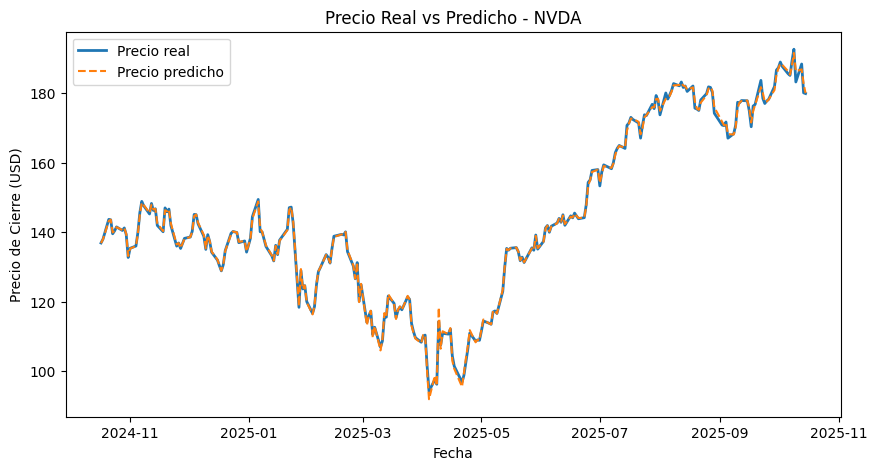

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Descarga de datos 12 meses de NVDA
nvda = yf.download("NVDA", start="2024-10-16", end="2025-10-16")

# Si hay MultiIndex en columnas, seleccionamos 'Close' correctamente
if isinstance(nvda.columns, pd.MultiIndex):
    nvda.columns = nvda.columns.get_level_values(0)  # toma solo el nivel principal

# Ahora 'Close' es una Serie segura
nvda['Close_prev'] = nvda['Close'].shift(1)
nvda['Rendimiento'] = np.log(nvda['Close'] / nvda['Close_prev'])

# Limpiar NaN
nvda = nvda.dropna()

# Variables
X = nvda[['Close_prev', 'Rendimiento']]
y = nvda['Close']

# Modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Predicciones
nvda['Prediccion'] = modelo.predict(X)

# Evaluación
r2 = r2_score(y, nvda['Prediccion'])
mae = mean_absolute_error(y, nvda['Prediccion'])
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

# Gráfica
plt.figure(figsize=(10,5))
plt.plot(nvda.index, nvda['Close'], label='Precio real', linewidth=2)
plt.plot(nvda.index, nvda['Prediccion'], label='Precio predicho', linestyle='--')
plt.title('Precio Real vs Predicho - NVDA')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend()
plt.show()

#Interpretación de Resultados
"""
El modelo de regresión lineal entrenado con el precio del día anterior y el rendimiento
logarítmico diario permite estimar el precio de cierre de NVDA. Un valor de R² cercano 
a 1 indicaría que el modelo explica gran parte de la variabilidad del precio, mientras 
que un valor bajo reflejaría que los precios tienen movimientos difíciles de predecir
mediante una relación lineal simple, lo cual es común en activos financieros volátiles.
Por su parte, el MAE muestra el error promedio en dólares entre el precio real y el predicho:
valores bajos implican que el modelo tiene buena precisión, aunque no captura eventos extremos
o cambios bruscos en el mercado. En general, este análisis lineal sirve para observar tendencias generales y patrones históricos,
pero no reemplaza modelos más complejos que consideren la volatilidad y otros factores externos del mercado.

"""